In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [31]:
df = pd.read_csv('kc_house_data.csv')

In [32]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [34]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [35]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [36]:
print(df.shape)

(21613, 21)


## Outliers

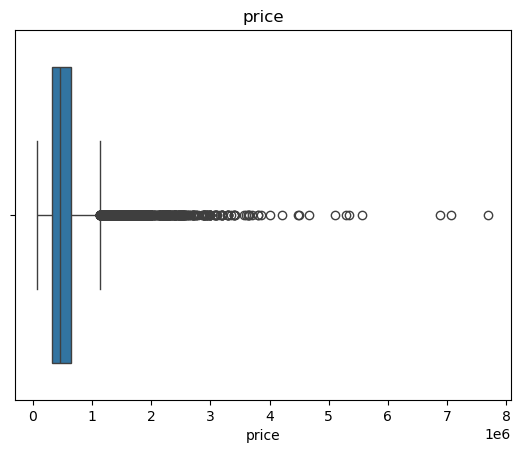

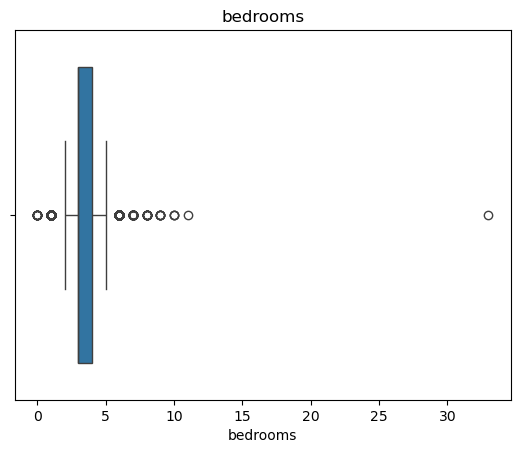

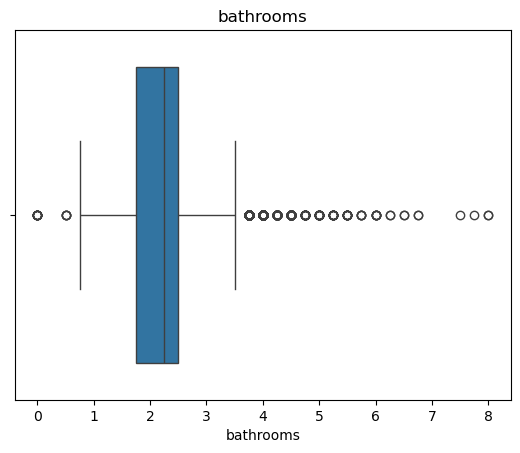

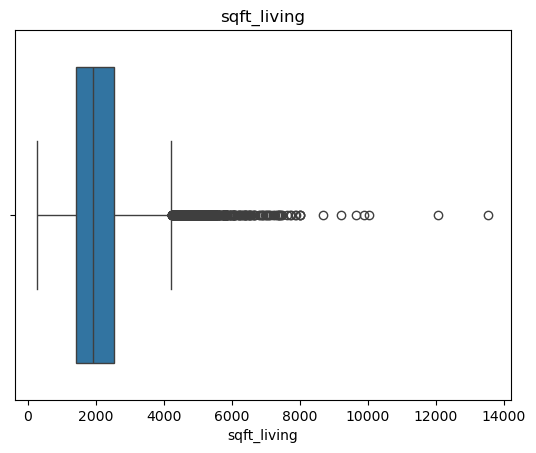

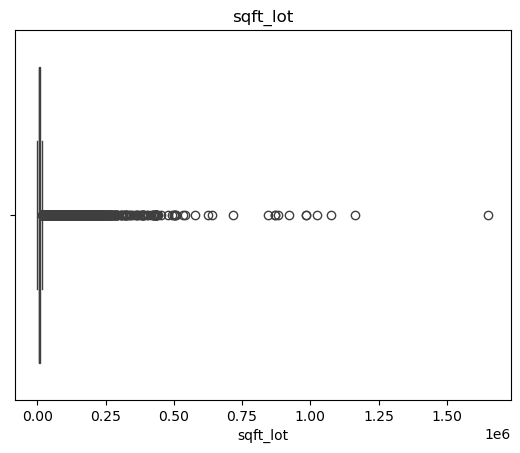

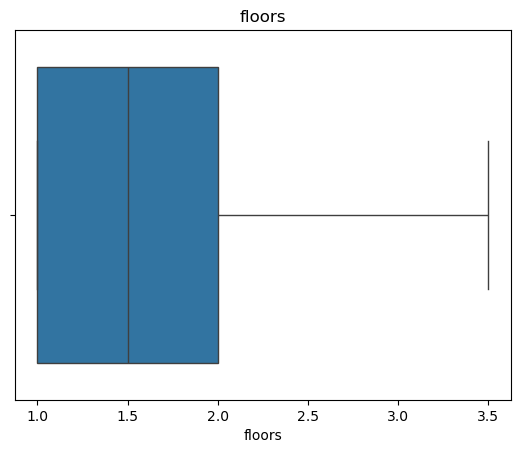

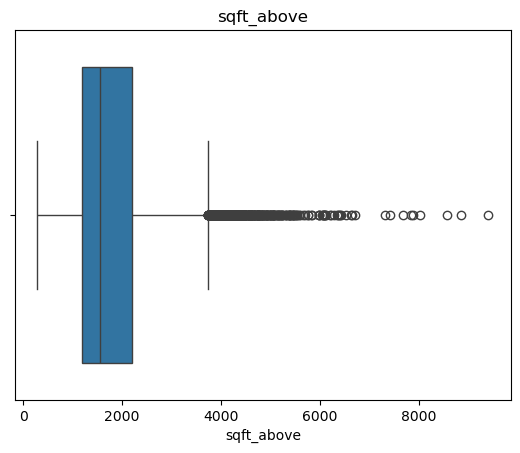

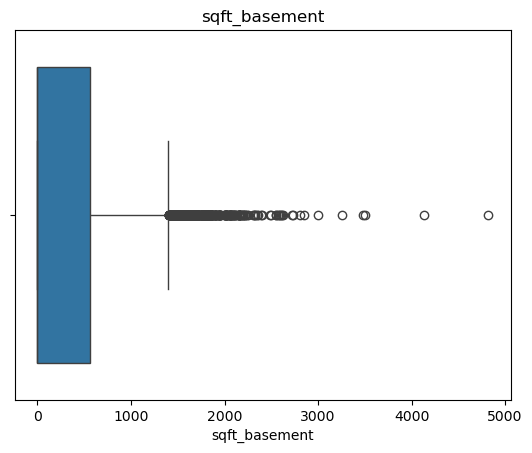

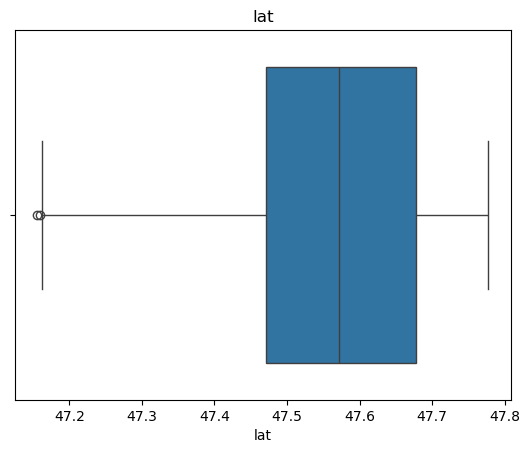

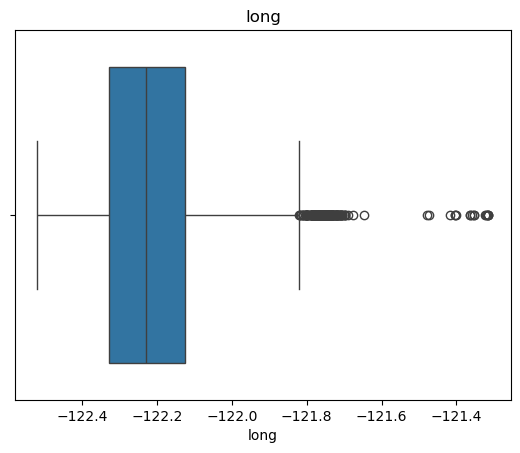

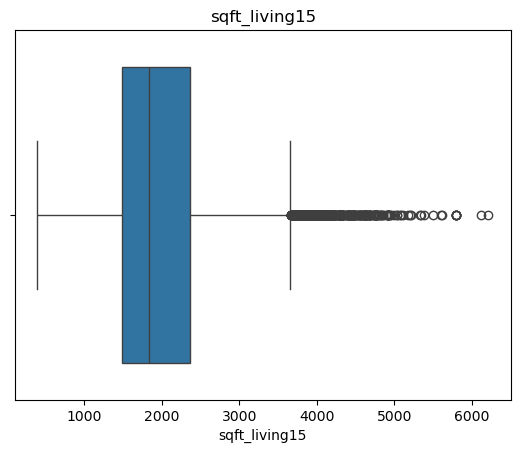

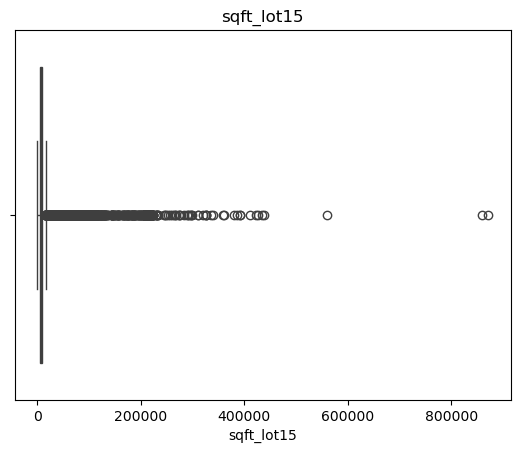

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'price',
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'sqft_above',
    'sqft_basement',
    'lat',
    'long',
    'sqft_living15',
    'sqft_lot15'
]


for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [38]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)


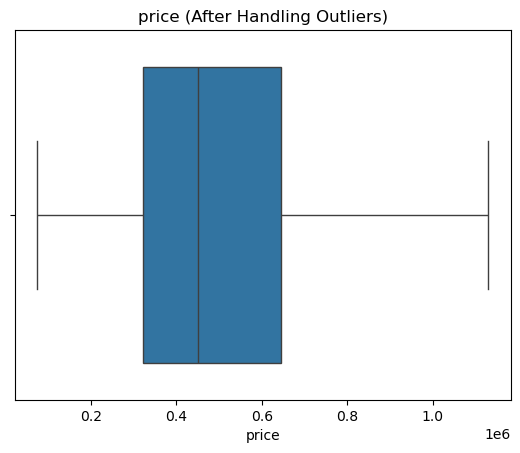

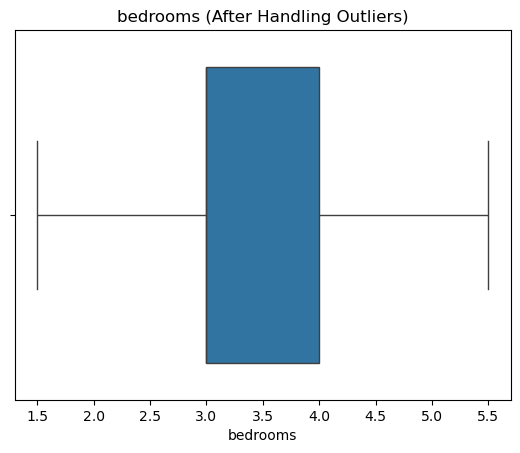

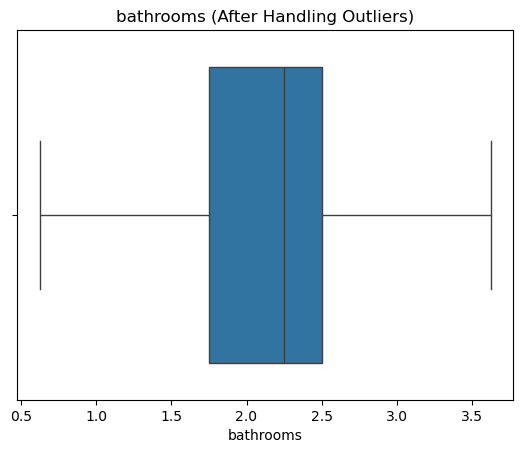

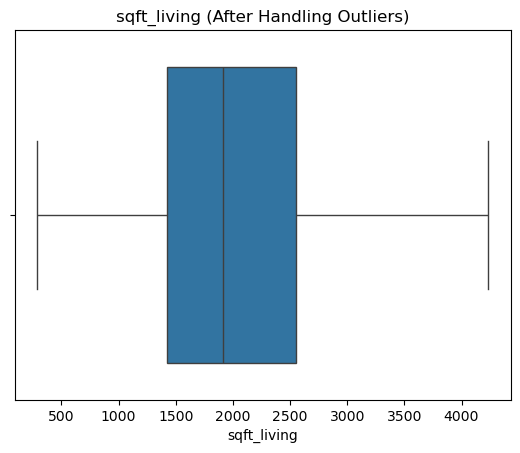

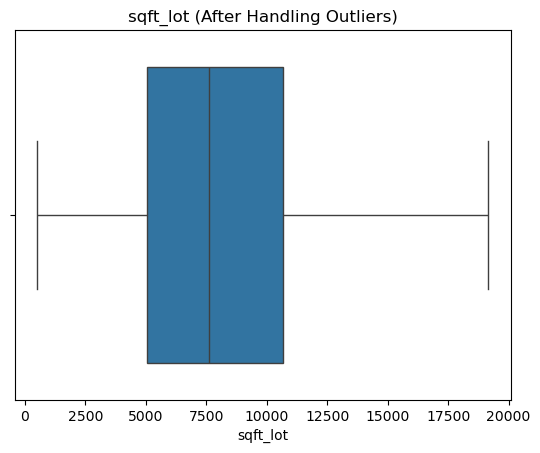

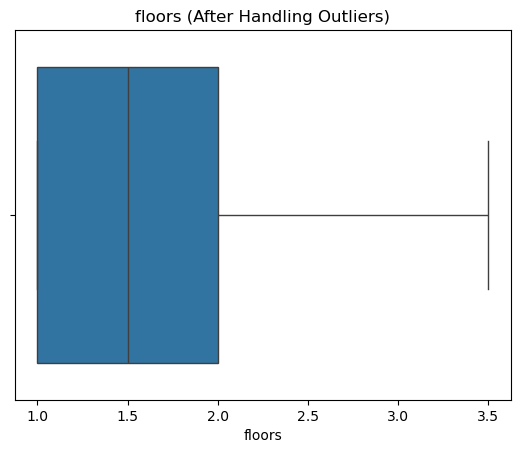

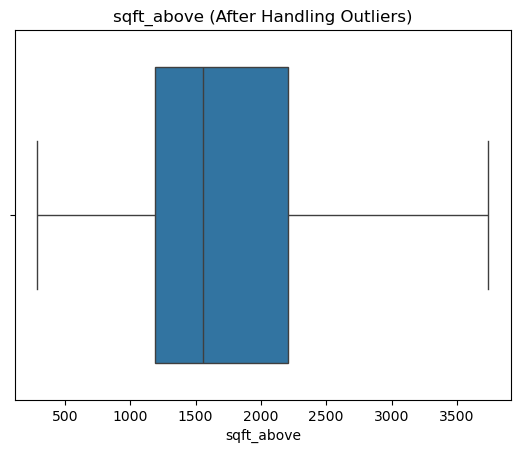

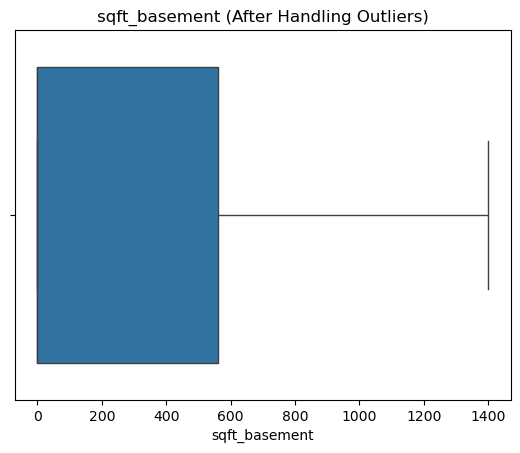

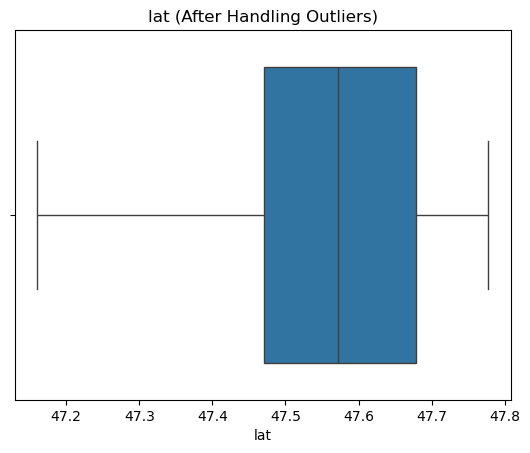

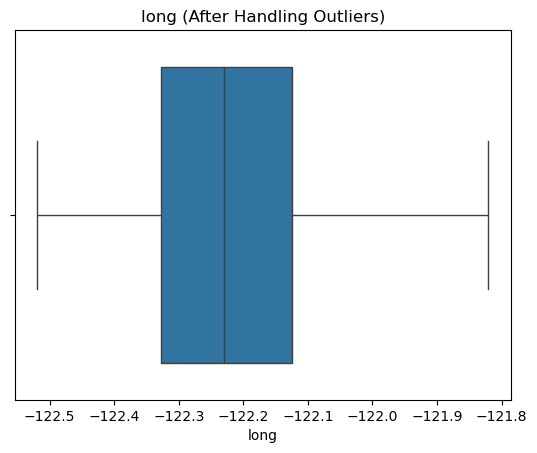

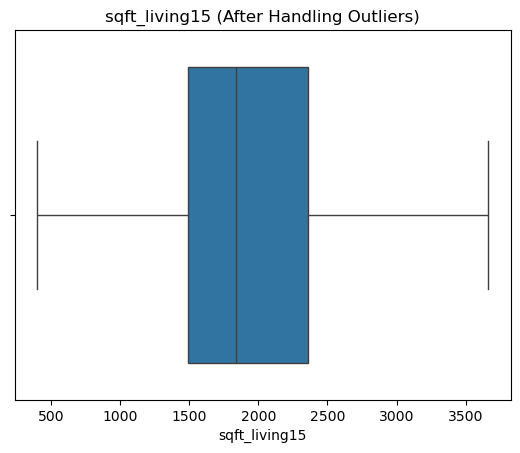

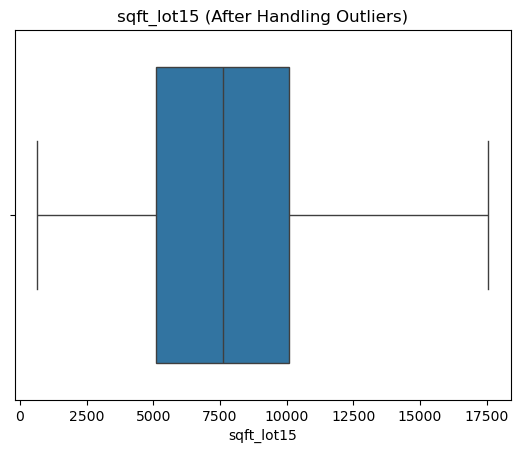

In [39]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col + " (After Handling Outliers)")
    plt.show()


In [40]:
df.drop(columns=['date'], inplace=True)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   price          21613 non-null  float64
 2   bedrooms       21613 non-null  float64
 3   bathrooms      21613 non-null  float64
 4   sqft_living    21613 non-null  float64
 5   sqft_lot       21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_above     21613 non-null  int64  
 12  sqft_basement  21613 non-null  int64  
 13  yr_built       21613 non-null  int64  
 14  yr_renovated   21613 non-null  int64  
 15  zipcode        21613 non-null  int64  
 16  lat            21613 non-null  float64
 17  long           21613 non-null  float64
 18  sqft_l

In [42]:
# Features (independent variables)
X = df.drop('price', axis=1)

# Target (dependent variable)
y = df['price']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Define Base Models

In [45]:
base_models = [
    ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42))
]

## Meta Model
Meta Model decodes decides how to combine predictions

In [46]:
meta_model = LinearRegression()

## Build Stacking Classifier

In [47]:
stack_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

In [48]:
stack_reg.fit(X_train, y_train)

,estimators,"[('dt', ...), ('rf', ...), ...]"
,final_estimator,LinearRegression()
,cv,5
,n_jobs,None
,passthrough,False
,verbose,0
,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1


In [49]:
y_pred = stack_reg.predict(X_test)

In [50]:
print("Accuracy:", r2_score(y_test, y_pred))

Accuracy: 0.898748635441564


In [53]:
# Create price categories
bins = [0, 300000, 600000, df['price'].max()]
labels = [0, 1, 2]  # Low, Medium, High

y_test_class = pd.cut(y_test, bins=bins, labels=labels)
y_pred_class = pd.cut(y_pred, bins=bins, labels=labels)

In [55]:
y_pred_class.isna().sum()

np.int64(76)

In [56]:
bins = [-float('inf'), 300000, 600000, float('inf')]
labels = [0, 1, 2]   # Low, Medium, High

In [57]:
y_test_class = pd.cut(y_test, bins=bins, labels=labels)
y_pred_class = pd.cut(y_pred, bins=bins, labels=labels)

In [58]:
y_test_class = y_test_class.astype(int)
y_pred_class = y_pred_class.astype(int)

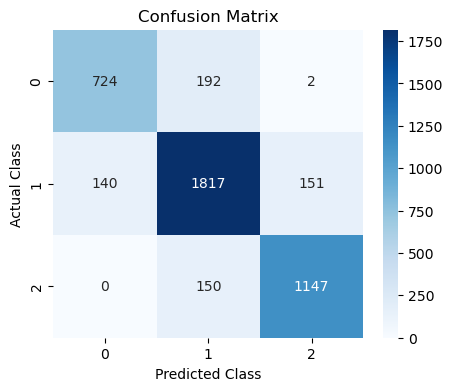

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_class, y_pred_class)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()


1️⃣ App Title & Description
Title:
🎯 Smart Loan Approval System – Stacking Model
Short Description:

“This system uses a Stacking Ensemble Machine Learning model to predict whether a loan will be approved by combining multiple ML models for better decision making.”



2️⃣ Input Section (Sidebar or Main Panel)
The user should enter the following applicant details:
    Applicant Income – Number input
    Co-Applicant Income – Number input
    Loan Amount – Number input
    Loan Amount Term – Number input
    Credit History – Radio button (Yes / No)
    Employment Status – Dropdown (Salaried / Self-Employed)
    Property Area – Dropdown (Urban / Semi-Urban / Rural)
📌 All inputs must be user-friendly and clearly labeled.


3️⃣ Model Architecture Display (IMPORTANT – For Stacking Understanding)
Display a read-only section explaining the stacking structure used:

Base Models Used:
    Logistic Regression
    Decision Tree
    Random Forest

Meta Model Used:
    Logistic Regression

📌 This helps students understand how stacking works internally.



4️⃣ Prediction Button
Add a button:

🔘 “Check Loan Eligibility (Stacking Model)”
On click:
    Collect user inputs
    Pass data to base models
    Use base model predictions as input to meta-model


5️⃣ Output Section (Main Result)
Display the prediction result clearly:
    ✅ Loan Approved (Green highlight)
    ❌ Loan Rejected (Red highlight)
    Display:
    📊 Base Model Predictions
        Logistic Regression → Approved / Rejected
        Decision Tree → Approved / Rejected
        Random Forest → Approved / Rejected
    🧠 Final Stacking Decision
    📈 Confidence Score (%) (if implemented)


6️⃣ Business Explanation (VERY IMPORTANT ⭐)
Display a short explanation in simple business language:

“Based on income, credit history, and combined predictions from multiple models, the applicant is likely / unlikely to repay the loan.
Therefore, the stacking model predicts loan approval / rejection.”

📌 This section is mandatory — marks will be deducted if missing.


7️⃣ UI Quality Guidelines (Mandatory)
    Use sidebar for inputs (preferred)
    Clean layout
    Clear headings
    Proper spacing
    Color-coded results (Green / Red)
